In [2]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io
from MedSAM.MedSAM_Inference import show_mask, show_box

In [3]:
df = pd.read_csv("data/results/dice_medsam.csv")
df.head()

,image_id,dice
0,cju0qkwl35piu0993l0dewei2,0.968581
1,cju0qoxqj9q6s0835b43399p4,0.967970
2,cju0qx73cjw570799j4n5cjze,0.967733
3,cju0roawvklrq0799vmjorwfv,0.961559
4,cju0rx1idathl0835detmsp84,0.950306


In [4]:
# 2. Statistiques descriptives complètes
stats = df['dice'].describe()
print(stats)

count    1000.000000
mean        0.954298
std         0.024184
min         0.629385
25%         0.944214
50%         0.959542
75%         0.969729
max         0.992421
Name: dice, dtype: float64


In [5]:
df.sort_values(by="dice")

,image_id,dice
199,cju2raxlosl630988jdbfy9b0,0.629385
403,cju3uhb79gcgr0871orbrbi3x,0.806905
663,cju76o55nymqd0871h31sph9w,0.841041
326,cju31t8xd17bk0835rnb893jk,0.847432
106,cju1fm3id6gl50801r3fok20c,0.857701
...,...,...
859,cju87vqa0ndwg0850onjdz7ol,0.986053
393,cju3tp94kfstl08181awh6z49,0.986214
976,cju8dqkrqu83i0818ev74qpxq,0.987485
39,cju17otoe119u0799nqcbl8n1,0.988247


In [6]:
img_folder = "data/Kvasir-SEG/images"
output_folder = "data/outputs"
masks_folder = "data/Kvasir-SEG/masks"

with open("data/Kvasir-SEG/kavsir_bboxes.json") as f:
    bboxes = json.load(f)

def show_segmentation(img):
    img_path = os.path.join(img_folder, img)
    img_id = os.path.splitext(img)[0]

    img_np = io.imread(img_path)
    if len(img_np.shape) == 2:
        img_3c = np.repeat(img_np[:, :, None], 3, axis=-1)
    else:
        img_3c = img_np

    medsam_seg_path = os.path.join(output_folder, "seg_" + os.path.basename(img_path))
    medsam_seg = io.imread(medsam_seg_path)
    medsam_seg[medsam_seg > 0] = 1

    true_seg_path = os.path.join(masks_folder, img)
    true_seg = io.imread(true_seg_path)[:,:,0]
    true_seg[true_seg > 0] = 1

    _, ax = plt.subplots(1, 3, figsize=(10, 5))

    ax[0].imshow(img_3c)
    ax[1].imshow(img_3c)
    ax[2].imshow(img_3c)

    for bbox in bboxes[img_id]["bbox"]:
        x_min, y_min = bbox["xmin"], bbox["ymin"]
        x_max, y_max = bbox["xmax"], bbox["ymax"]
        box = np.array([x_min, y_min, x_max, y_max])

        show_box(box, ax[0])
        show_box(box, ax[1])

    show_mask(medsam_seg, ax[1])
    show_mask(true_seg, ax[2])

    ax[0].set_title("Input Image and Bounding Box")
    ax[1].set_title("MedSAM Segmentation")
    ax[2].set_title("Ground Truth")

    plt.show()

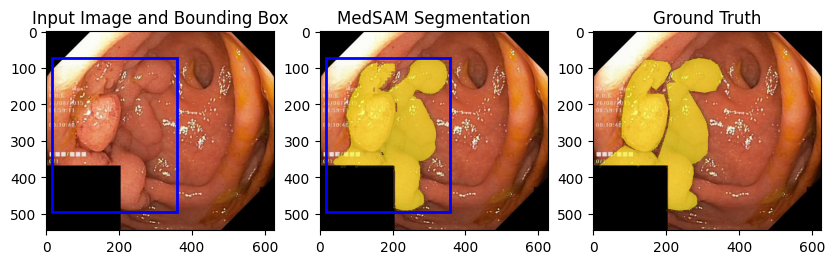

In [7]:
show_segmentation("cju410dnfl0960755y8lu8d79.jpg")

In [1]:
import pandas as pd
import json
import os

# 1. Charger les résultats globaux
df_dice = pd.read_csv("data/results/dice_medsam.csv")

# 2. Fonction pour extraire les IDs (noms de fichiers sans extension) d'un JSON COCO
def get_ids_from_json(json_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    # On récupère le nom du fichier et on enlève le .jpg pour correspondre à ton image_id
    return [os.path.splitext(img['file_name'])[0] for img in data['images']]

# 3. Chemins des fichiers de split
split_dir = 'data/Kvasir-SEG'
splits = {
    "TRAIN": os.path.join(split_dir, "train.json"),
    "VAL": os.path.join(split_dir, "val.json"),
    "TEST": os.path.join(split_dir, "test.json")
}

# 4. Calcul et affichage des statistiques par split
print("=== Statistiques DICE par Split (Kvasir-SEG) ===")
print("-" * 50)

summary_list = []

for name, path in splits.items():
    if os.path.exists(path):
        ids = get_ids_from_json(path)
        
        # Filtrer le DataFrame global pour ne garder que les images du split
        df_split = df_dice[df_dice['image_id'].isin(ids)]
        
        stats = df_split['dice'].describe()
        print(f"\nSplit {name} ({len(df_split)} images) :")
        print(stats)
        
        # Optionnel : stockage pour un tableau récapitulatif
        summary_list.append({
            "Split": name,
            "Mean": stats['mean'],
            "Median": stats['50%'],
            "Std": stats['std'],
            "Min": stats['min'],
            "Max": stats['max']
        })
    else:
        print(f"\nFichier {path} introuvable.")

# 5. Affichage d'un tableau récapitulatif propre
print("\n" + "="*60)
print("TABLEAU RÉCAPITULATIF")
print("="*60)
summary_df = pd.DataFrame(summary_list)
print(summary_df.to_string(index=False))

=== Statistiques DICE par Split (Kvasir-SEG) ===
--------------------------------------------------

Split TRAIN (800 images) :
count    800.000000
mean       0.954720
std        0.021593
min        0.806905
25%        0.944258
50%        0.959587
75%        0.969656
max        0.992421
Name: dice, dtype: float64

Split VAL (100 images) :
count    100.000000
mean       0.953558
std        0.022242
min        0.874240
25%        0.943697
50%        0.959043
75%        0.969458
max        0.981697
Name: dice, dtype: float64

Split TEST (100 images) :
count    100.000000
mean       0.951666
std        0.040432
min        0.629385
25%        0.941749
50%        0.959893
75%        0.971275
max        0.984346
Name: dice, dtype: float64

TABLEAU RÉCAPITULATIF
Split     Mean   Median      Std      Min      Max
TRAIN 0.954720 0.959587 0.021593 0.806905 0.992421
  VAL 0.953558 0.959043 0.022242 0.874240 0.981697
 TEST 0.951666 0.959893 0.040432 0.629385 0.984346
